In [55]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
import tsfel
import time
import numpy as np

In [56]:
nSet = 0
fileTS = os.path.join(os.getcwd(), "pdfTimeSeries{:d}.pkl".format(nSet))
pdfTS = pd.read_pickle(fileTS)

In [57]:
pdfTS

,u,y,i,e
0,0.000000,-0.076287,9N6FK96G8,-0.076287
1,0.000000,0.019506,9N6FK96G8,0.019506
2,0.000000,-0.073928,9N6FK96G8,-0.073928
3,0.000000,0.044727,9N6FK96G8,0.044727
4,0.000000,-0.010317,9N6FK96G8,-0.010317
...,...,...,...,...
718,-0.465181,-0.449052,UMTMULQVC,0.016130
719,-0.465181,-0.417802,UMTMULQVC,0.047379
720,-0.465181,-0.510018,UMTMULQVC,-0.044837
721,-0.465181,-0.507332,UMTMULQVC,-0.042151


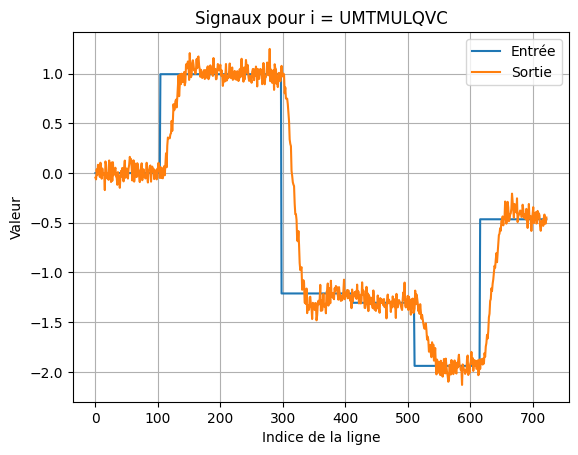

In [58]:
identifiant = "UMTMULQVC"

pdfTS_filtre = pdfTS[pdfTS["i"] == identifiant]

pdfTS_filtre["u"].plot(label="Entrée")
pdfTS_filtre["y"].plot(label="Sortie")


plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [59]:
fileEF = os.path.join(os.getcwd(), "pdfFeatures{:d}.pkl".format(nSet))
pdfEF = pd.read_pickle(fileEF)

In [60]:
pdfEF

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.030425,0.057124,1.0,0.016903,0.799343,2.0,8.0,-0.073928,0.044727,0.1,...,0.004341,0.003173,0.001785,0.00109,0.000761,0.00059,0.000489,0.000423,6.0,9N6FK96G8
1,0.034108,0.071956,2.0,0.018949,0.870813,2.0,8.0,-0.068527,0.031442,0.1,...,0.003611,0.003788,0.003008,0.002341,0.001897,0.001597,0.001382,0.001221,4.0,9N6FK96G8
2,0.042274,0.083902,1.0,0.023486,0.962404,2.0,8.0,-0.105961,0.016858,0.1,...,0.001518,0.000854,0.000852,0.000831,0.000794,0.000749,0.000702,0.000656,4.0,9N6FK96G8
3,0.033578,0.080128,2.0,0.018654,0.551002,2.0,8.0,-0.104259,0.021024,0.1,...,0.007749,0.006425,0.00425,0.003015,0.002334,0.001921,0.001645,0.001445,3.0,9N6FK96G8
4,0.023003,0.049324,1.0,0.012779,1.067663,2.0,8.0,-0.015203,0.035602,0.1,...,0.0012,0.001165,0.000987,0.000811,0.000682,0.00059,0.00052,0.000465,4.0,9N6FK96G8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49311,0.058049,0.090205,1.0,0.032249,0.799835,2.0,8.0,-0.087101,0.032083,0.1,...,0.031444,0.015267,0.019952,0.027048,0.031054,0.032461,0.032345,0.031438,0.0,UMTMULQVC
49312,0.035514,0.066874,1.0,0.01973,0.918799,2.0,8.0,-0.038623,0.032083,0.1,...,0.017774,0.017436,0.023716,0.028415,0.030289,0.030336,0.02944,0.028123,0.0,UMTMULQVC
49313,0.035254,0.063878,1.0,0.019586,0.700099,2.0,8.0,-0.038623,0.070625,0.1,...,0.012935,0.018426,0.027143,0.031986,0.033404,0.032951,0.031636,0.029988,0.0,UMTMULQVC
49314,0.041431,0.080162,1.0,0.023017,1.048823,2.0,8.0,-0.073158,0.060267,0.1,...,0.032227,0.018178,0.02272,0.029591,0.033423,0.034674,0.034409,0.033364,0.0,UMTMULQVC


***DATA PREP***

Step 1,2,3 : Cleaning, scaling and spliting data

In [61]:
import numpy as np
import pandas as pd

# Copie du dataframe de features
df = pdfEF.copy()

# On enlève l'identifiant des features si la colonne existe
X = df.drop(columns=["i"], errors="ignore")

# Conversion en numérique
X = X.apply(pd.to_numeric, errors="coerce")

# Remplacement des valeurs infinies
X = X.replace([np.inf, -np.inf], np.nan)

# Suppression des colonnes complètement vides
X = X.dropna(axis=1, how="all")

# Remplacement des valeurs manquantes par la médiane
X = X.fillna(X.median())

# Suppression des colonnes constantes
X = X.loc[:, X.nunique(dropna=True) > 1]

print("Shape après cleaning :", X.shape)

Shape après cleaning : (49316, 246)


Split

In [62]:
from sklearn.model_selection import train_test_split

# Indices pour retrouver les lignes originales après le split
indices = np.arange(X.shape[0])

X_train, X_test, idx_train, idx_test = train_test_split(
    X,
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

X_train : (39452, 246)
X_test : (9864, 246)


Scaling

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling terminé")

Scaling terminé


In [64]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.7, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Nombre de features au départ :", X.shape[1])
print("Nombre de composantes PCA gardées :", X_train_pca.shape[1])
print("Variance expliquée :", round(pca.explained_variance_ratio_.sum(), 4))

Nombre de features au départ : 246
Nombre de composantes PCA gardées : 14
Variance expliquée : 0.7042


**Kernel Density Estimation**

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
import time

t0 = time.time()

# Split du train PCA en :
# - une partie pour entraîner la KDE
# - une partie pour définir le seuil de vraisemblance
X_kde_train, X_kde_val = train_test_split(
    X_train_pca,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# Échantillon pour accélérer la KDE
n_sample = min(3000, len(X_kde_train))

sample_idx = np.random.choice(
    len(X_kde_train),
    size=n_sample,
    replace=False
)

X_kde_sample = X_kde_train[sample_idx]

print("Taille utilisée pour KDE :", X_kde_sample.shape)

# Intervalle borné de recherche du bandwidth
bandwidth_min = 0.1
bandwidth_max = 2.0
nb_tests = 10

bandwidth_values = np.linspace(
    bandwidth_min,
    bandwidth_max,
    nb_tests
)

params = {
    "bandwidth": bandwidth_values
}

# Recherche du meilleur bandwidth
grid = GridSearchCV(
    KernelDensity(kernel="gaussian"),
    params,
    cv=3
)

grid.fit(X_kde_sample)

best_bandwidth = grid.best_params_["bandwidth"]

print("Meilleur bandwidth trouvé :", best_bandwidth)

# KDE final avec le meilleur bandwidth
kde = KernelDensity(
    kernel="gaussian",
    bandwidth=best_bandwidth
)

kde.fit(X_kde_sample)

print("Temps entraînement KDE :", round(time.time() - t0, 2), "secondes")

Taille utilisée pour KDE : (3000, 14)
Meilleur bandwidth trouvé : 1.1555555555555557
Temps entraînement KDE : 2.75 secondes


In [66]:
# Log-vraisemblance sur validation et test
val_log_likelihood = kde.score_samples(X_kde_val)
test_log_likelihood = kde.score_samples(X_test_pca)

# Seuil : les 20% avec la plus faible vraisemblance sont considérés comme points de bord
threshold = np.percentile(val_log_likelihood, 20)

# Détection sur le test
test_is_border = test_log_likelihood < threshold

print("Seuil de log-vraisemblance :", threshold)
print("Nombre de points test :", len(test_is_border))
print("Points sur les bords :", test_is_border.sum())
print("Pourcentage :", round(test_is_border.mean() * 100, 2), "%")

Seuil de log-vraisemblance : -29.61195977229299
Nombre de points test : 9864
Points sur les bords : 1918
Pourcentage : 19.44 %


In [67]:
df_test_result = df.iloc[idx_test].copy()

df_test_result["log_likelihood"] = test_log_likelihood
df_test_result["is_border"] = test_is_border

df_test_result[["log_likelihood", "is_border"]].head(20)

,log_likelihood,is_border
48186,-24.584438,False
38307,-28.847422,False
47752,-24.591180,False
44372,-24.120674,False
147,-26.704877,False
14174,-27.610164,False
28078,-43.796944,True
6095,-23.595587,False
37486,-24.547579,False
33555,-25.574186,False


In [68]:
df_test_result.sort_values("log_likelihood")[["log_likelihood", "is_border"]].head(20)

,log_likelihood,is_border
41593,-145.901582,True
29468,-94.904345,True
5501,-90.591416,True
30240,-89.299469,True
7225,-88.102401,True
20499,-84.132217,True
26522,-81.507340,True
584,-78.346654,True
23261,-76.086132,True
3910,-74.869459,True


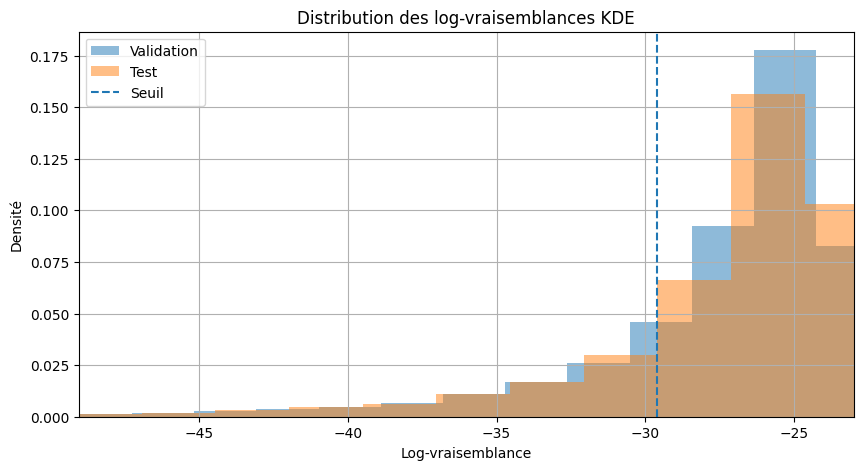

In [69]:
import matplotlib.pyplot as plt

all_scores = np.concatenate([val_log_likelihood, test_log_likelihood])

xmin = np.percentile(all_scores, 1)
xmax = np.percentile(all_scores, 99)

plt.figure(figsize=(10, 5))

plt.hist(
    val_log_likelihood,
    bins=50,
    density=True,
    alpha=0.5,
    label="Validation"
)

plt.hist(
    test_log_likelihood,
    bins=50,
    density=True,
    alpha=0.5,
    label="Test"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Seuil"
)

plt.xlim(xmin, xmax)

plt.xlabel("Log-vraisemblance")
plt.ylabel("Densité")
plt.title("Distribution des log-vraisemblances KDE")
plt.legend()
plt.grid()
plt.show()

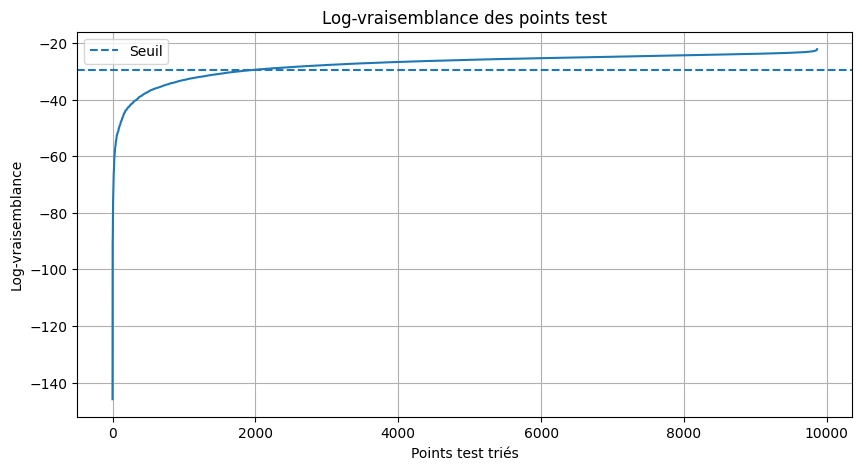

In [70]:
sorted_scores = np.sort(test_log_likelihood)

plt.figure(figsize=(10, 5))

plt.plot(sorted_scores)
plt.axhline(threshold, linestyle="--", label="Seuil")

plt.xlabel("Points test triés")
plt.ylabel("Log-vraisemblance")
plt.title("Log-vraisemblance des points test")
plt.legend()
plt.grid()
plt.show()

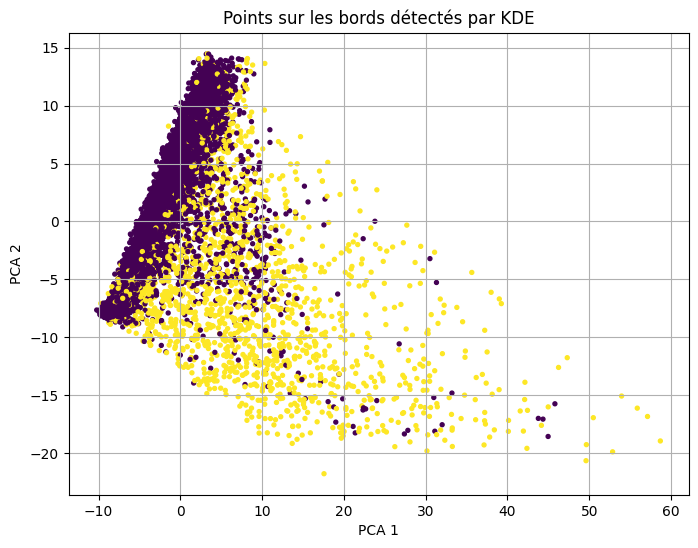

In [71]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=test_is_border,
    s=8
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Points sur les bords détectés par KDE")
plt.grid()
plt.show()

---
****Fichier avec défaut 1****
---

In [72]:
nSet = 0
fileTS_def = os.path.join(os.getcwd(), "pdfTimeSeries1.pkl".format(nSet))
pdfTS_def = pd.read_pickle(fileTS_def)

In [73]:
pdfTS_def

,u,y,i,e
0,0.000000,-0.178862,VJG2XDS11,-0.178862
1,0.000000,0.009132,VJG2XDS11,0.009132
2,0.000000,0.058681,VJG2XDS11,0.058681
3,0.000000,0.010686,VJG2XDS11,0.010686
4,0.000000,-0.001032,VJG2XDS11,-0.001032
...,...,...,...,...
1805,0.933992,0.924232,RJ9RSGP8N,-0.009760
1806,0.933992,1.047756,RJ9RSGP8N,0.113764
1807,0.933992,0.923011,RJ9RSGP8N,-0.010981
1808,0.933992,0.878074,RJ9RSGP8N,-0.055918


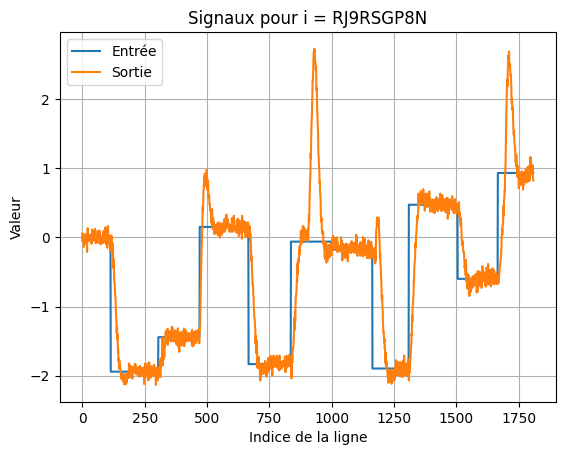

In [74]:
identifiant = "RJ9RSGP8N"

pdfTSdef_filtre = pdfTS_def[pdfTS_def["i"] == identifiant]

pdfTSdef_filtre["u"].plot(label="Entrée")
pdfTSdef_filtre["y"].plot(label="Sortie")

plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [75]:
fileEF_default = os.path.join(os.getcwd(), "pdfFeatures1.pkl".format(nSet))
pdfEF_default = pd.read_pickle(fileEF_default)

In [76]:
pdfEF_default

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.079972,0.070585,1.0,0.044429,0.743867,2.0,8.0,-0.16203,0.058681,0.1,...,0.006549,0.002512,0.000561,0.000079,0.000034,0.000084,0.000139,0.00018,7.0,VJG2XDS11
1,0.113216,0.108242,1.0,0.062898,1.067862,2.0,8.0,-0.16203,0.070568,0.1,...,0.012497,0.004955,0.001334,0.000357,0.000192,0.000225,0.000287,0.000336,5.0,VJG2XDS11
2,0.080514,0.102533,1.0,0.04473,0.673056,2.0,8.0,-0.071974,0.020168,0.1,...,0.00544,0.003927,0.002602,0.001843,0.001432,0.001188,0.001027,0.000911,3.0,VJG2XDS11
3,0.041541,0.086099,1.0,0.023078,0.947138,2.0,8.0,-0.089413,0.004123,0.1,...,0.000665,0.000911,0.000832,0.000722,0.000634,0.000565,0.000509,0.000463,4.0,VJG2XDS11
4,0.032314,0.046819,1.0,0.017952,0.264517,2.0,8.0,-0.089413,0.017185,0.1,...,0.002195,0.002557,0.002071,0.001648,0.001362,0.001164,0.001019,0.000907,6.0,VJG2XDS11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9978,0.043084,0.066947,1.0,0.023935,0.874975,2.0,8.0,-0.070085,0.036081,0.1,...,0.050158,0.070849,0.107633,0.130185,0.1382,0.137748,0.133162,0.12683,0.0,RJ9RSGP8N
9979,0.056206,0.071727,1.0,0.031225,1.017963,2.0,8.0,-0.070085,0.086244,0.1,...,0.062573,0.06251,0.095131,0.120334,0.131557,0.133555,0.130661,0.125468,0.0,RJ9RSGP8N
9980,0.098005,0.111591,1.0,0.054447,1.168855,2.0,8.0,-0.100425,0.089533,0.1,...,0.062877,0.070356,0.103128,0.127363,0.137766,0.139117,0.135697,0.130065,0.0,RJ9RSGP8N
9981,0.067764,0.08189,1.0,0.037647,0.58618,2.0,8.0,-0.01493,0.034071,0.1,...,0.056094,0.081339,0.119263,0.141201,0.148211,0.146773,0.141318,0.134241,0.0,RJ9RSGP8N


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recalcul du statut de chaque fenêtre défaut à partir du seuil KDE
df_default_result["is_border"] = df_default_result["log_likelihood"] < threshold
df_default_result["is_normal"] = df_default_result["log_likelihood"] >= threshold

# Score d'anomalie
df_default_result["anomaly_score"] = -df_default_result["log_likelihood"]

df_default_result[["i", "log_likelihood", "is_normal", "is_border", "anomaly_score"]].head()

NameError: name 'df_default_result' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recalcul du statut de chaque fenêtre défaut à partir du seuil KDE
df_default_result["is_border"] = df_default_result["log_likelihood"] < threshold
df_default_result["is_normal"] = df_default_result["log_likelihood"] >= threshold

# Score d'anomalie
df_default_result["anomaly_score"] = -df_default_result["log_likelihood"]

df_default_result[["i", "log_likelihood", "is_normal", "is_border", "anomaly_score"]].head()

,i,log_likelihood,is_normal,is_border,anomaly_score
0,VJG2XDS11,-25.944602,True,False,25.944602
1,VJG2XDS11,-30.356473,False,True,30.356473
2,VJG2XDS11,-26.222130,True,False,26.222130
3,VJG2XDS11,-28.666309,True,False,28.666309
4,VJG2XDS11,-26.049400,True,False,26.049400


In [ ]:
seuil_id = 10

summary_default["id_detected_faulty"] = summary_default["pct_windows_anormales"] >= seuil_id

summary_default[[
    "i",
    "nb_windows",
    "nb_windows_anormales",
    "pct_windows_anormales",
    "id_detected_faulty"
]].head(20)

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,id_detected_faulty
0,2U2HN8U8D,323,108,33.436533,True
1,3A2AKKKHI,314,82,26.114650,True
2,48WK1UQQO,329,102,31.003040,True
3,6QXC4QTK2,203,65,32.019704,True
4,87UUY7547,242,76,31.404959,True
5,8IWYZ3WFE,187,58,31.016043,True
6,9DI4D2S36,162,65,40.123457,True
7,AQ86JGMKW,232,88,37.931034,True
8,AZTVA5ZWX,259,92,35.521236,True
9,D3R3JJGIL,314,102,32.484076,True


In [ ]:
print("Nombre total d'identifiants défauts :", len(summary_default))
print("Identifiants détectés faulty :", summary_default["id_detected_faulty"].sum())
print("Pourcentage détecté :", round(summary_default["id_detected_faulty"].mean() * 100, 2), "%")

Nombre total d'identifiants défauts : 40
Identifiants détectés faulty : 40
Pourcentage détecté : 100.0 %


In [ ]:
summary_default.sort_values(
    by="pct_windows_anormales",
    ascending=False
).head(20)

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,mean_log_likelihood,min_log_likelihood,max_anomaly_score,mean_anomaly_score,id_detected_faulty
17,KIQ82T2TF,142,67,47.183099,-32.645235,-99.389790,99.389790,32.645235,True
6,9DI4D2S36,162,65,40.123457,-35.098146,-179.593110,179.593110,35.098146,True
31,V25U5JPDP,204,79,38.725490,-44.834270,-469.140161,469.140161,44.834270,True
20,NYHQFSS36,208,80,38.461538,-44.660736,-732.523266,732.523266,44.660736,True
33,VJG2XDS11,272,104,38.235294,-32.830486,-218.193186,218.193186,32.830486,True
15,GAJOFQ4RL,205,78,38.048780,-31.555565,-147.167404,147.167404,31.555565,True
36,W8OLFRM09,179,68,37.988827,-32.003201,-144.260016,144.260016,32.003201,True
7,AQ86JGMKW,232,88,37.931034,-41.438227,-478.007931,478.007931,41.438227,True
24,QRJ024QY0,177,66,37.288136,-39.033714,-469.180664,469.180664,39.033714,True
30,UC17PKQ2L,271,101,37.269373,-31.398052,-117.045140,117.045140,31.398052,True


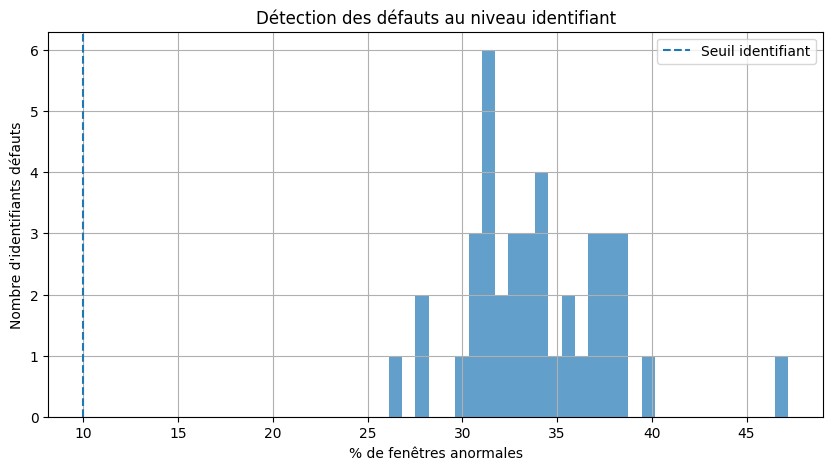

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    summary_default["pct_windows_anormales"],
    bins=30,
    alpha=0.7
)

plt.axvline(
    seuil_id,
    linestyle="--",
    label="Seuil identifiant"
)

plt.xlabel("% de fenêtres anormales")
plt.ylabel("Nombre d'identifiants défauts")
plt.title("Détection des défauts au niveau identifiant")
plt.legend()
plt.grid()
plt.show()

---
**Jour 2**
---

**Dataset 2**

In [ ]:
fileTS2 = os.path.join(os.getcwd(), "pdfTimeSeries2.pkl".format(nSet))
pdfTS2 = pd.read_pickle(fileTS2)

In [ ]:
pdfTS2

,u,y,i,e
0,0.000000,-0.056065,IQVYTIVZI,-0.056065
1,0.000000,0.004750,IQVYTIVZI,0.004750
2,0.000000,-0.088224,IQVYTIVZI,-0.088224
3,0.000000,0.103965,IQVYTIVZI,0.103965
4,0.000000,-0.105212,IQVYTIVZI,-0.105212
...,...,...,...,...
1129,-1.499424,-1.521239,9DLVY2MTM,-0.021815
1130,-1.499424,-1.464248,9DLVY2MTM,0.035176
1131,-1.499424,-1.528087,9DLVY2MTM,-0.028663
1132,-1.499424,-1.509753,9DLVY2MTM,-0.010329


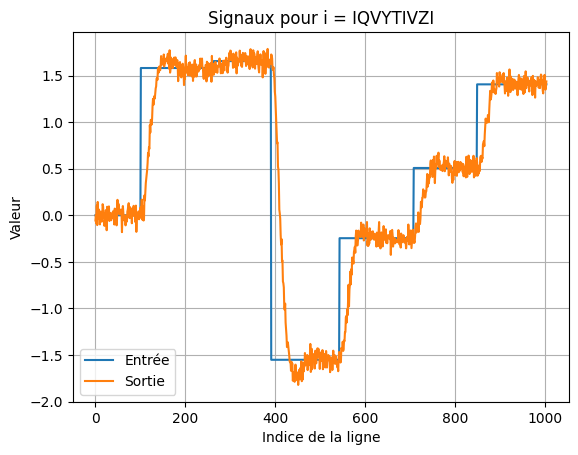

In [ ]:
identifiant = "IQVYTIVZI"

pdfTS2_filtre = pdfTS2[pdfTS2["i"] == identifiant]

pdfTS2_filtre["u"].plot(label="Entrée")
pdfTS2_filtre["y"].plot(label="Sortie")


plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [ ]:
fileEF2 = os.path.join(os.getcwd(), "pdfFeatures2.pkl".format(nSet))
pdfEF2 = pd.read_pickle(fileEF2)

In [ ]:
pdfEF2

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.059216,0.044443,1.0,0.032898,0.804866,2.0,8.0,-0.088224,0.064545,0.1,...,0.002374,0.002111,0.001411,0.001006,0.000791,0.000666,0.000583,0.000523,7.0,IQVYTIVZI
1,0.044947,0.057335,1.0,0.02497,0.595348,2.0,8.0,-0.068292,0.039978,0.1,...,0.00388,0.002158,0.001157,0.000822,0.000707,0.000652,0.000613,0.000579,5.0,IQVYTIVZI
2,0.043168,0.077023,1.0,0.023982,0.854625,2.0,8.0,-0.068292,0.039978,0.1,...,0.002692,0.001613,0.001324,0.00114,0.001017,0.000925,0.000849,0.000783,3.0,IQVYTIVZI
3,0.0533,0.094651,1.0,0.029611,0.786584,2.0,8.0,-0.098149,0.055082,0.1,...,0.010799,0.00719,0.00392,0.00242,0.001731,0.001374,0.001161,0.001017,3.0,IQVYTIVZI
4,0.067602,0.08591,1.0,0.037556,0.725336,2.0,8.0,-0.113625,0.055082,0.1,...,0.002384,0.002523,0.002059,0.001659,0.001402,0.001226,0.001096,0.000994,5.0,IQVYTIVZI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37364,0.029434,0.079779,1.0,0.016352,0.681912,2.0,8.0,0.010078,0.060526,0.1,...,0.126341,0.151998,0.23587,0.294779,0.319444,0.322508,0.314392,0.301166,0.0,9DLVY2MTM
37365,0.019913,0.056061,2.0,0.011063,0.7887,2.0,8.0,-0.068776,0.0105,0.1,...,0.121303,0.184962,0.284286,0.343689,0.364472,0.363008,0.350744,0.333949,0.0,9DLVY2MTM
37366,0.026585,0.059124,2.0,0.01477,0.736369,2.0,8.0,-0.068776,0.03031,0.1,...,0.142319,0.152249,0.233226,0.294619,0.321876,0.32668,0.319572,0.306864,0.0,9DLVY2MTM
37367,0.109663,0.140839,2.0,0.060924,1.078961,2.0,8.0,-0.128093,0.03031,0.1,...,0.129391,0.218209,0.327399,0.387338,0.405553,0.400808,0.385341,0.365649,0.0,9DLVY2MTM


In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

In [108]:
# dataset sain connu
df_normal = pdfEF.copy()

# dataset défaut 1 connu
df_fault1 = pdfEF_default.copy()

# dataset mixte à classifier
df_mix = pdfEF2.copy()

In [126]:
ID_COL = "i"
df_normal.columns = df_normal.columns.astype(str).str.strip()
df_fault1.columns = df_fault1.columns.astype(str).str.strip()
df_mix.columns = df_mix.columns.astype(str).str.strip()

if ID_COL not in df_normal.columns:
    raise ValueError(f"La colonne {ID_COL} n'existe pas dans df_normal")

if ID_COL not in df_fault1.columns:
    raise ValueError(f"La colonne {ID_COL} n'existe pas dans df_fault1")

if ID_COL not in df_mix.columns:
    raise ValueError(f"La colonne {ID_COL} n'existe pas dans df_mix")

In [127]:
common_cols = sorted(
    list(
        (set(df_normal.columns) & set(df_fault1.columns) & set(df_mix.columns))
        - {ID_COL}
    )
)

print("Nombre de colonnes communes avant conversion :", len(common_cols))

Nombre de colonnes communes avant conversion : 274


In [129]:
numeric_cols = []

for col in common_cols:
    normal_col = pd.to_numeric(
        df_normal[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

    fault1_col = pd.to_numeric(
        df_fault1[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

    mix_col = pd.to_numeric(
        df_mix[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

    if normal_col.notna().any() and fault1_col.notna().any() and mix_col.notna().any():
        numeric_cols.append(col)

print("Nombre de features numériques communes :", len(numeric_cols))
print(numeric_cols)

if len(numeric_cols) == 0:
    raise ValueError("Aucune feature numérique commune trouvée.")

Nombre de features numériques communes : 274
['e_Absolute energy', 'e_Area under the curve', 'e_Autocorrelation', 'e_Average power', 'e_Centroid', 'e_ECDF Percentile Count_0', 'e_ECDF Percentile Count_1', 'e_ECDF Percentile_0', 'e_ECDF Percentile_1', 'e_ECDF_0', 'e_ECDF_1', 'e_ECDF_2', 'e_ECDF_3', 'e_ECDF_4', 'e_ECDF_5', 'e_ECDF_6', 'e_ECDF_7', 'e_ECDF_8', 'e_ECDF_9', 'e_Entropy', 'e_FFT mean coefficient_0', 'e_FFT mean coefficient_1', 'e_FFT mean coefficient_2', 'e_FFT mean coefficient_3', 'e_FFT mean coefficient_4', 'e_FFT mean coefficient_5', 'e_Fundamental frequency', 'e_Histogram_0', 'e_Histogram_1', 'e_Histogram_2', 'e_Histogram_3', 'e_Histogram_4', 'e_Histogram_5', 'e_Histogram_6', 'e_Histogram_7', 'e_Histogram_8', 'e_Histogram_9', 'e_Human range energy', 'e_Interquartile range', 'e_Kurtosis', 'e_LPCC_0', 'e_LPCC_1', 'e_LPCC_2', 'e_LPCC_3', 'e_LPCC_4', 'e_LPCC_5', 'e_LPCC_6', 'e_LPCC_7', 'e_LPCC_8', 'e_LPCC_9', 'e_MFCC_0', 'e_MFCC_1', 'e_MFCC_10', 'e_MFCC_11', 'e_MFCC_2', 'e_MFC

In [137]:
def aggregate_features_by_id(df, id_col, numeric_cols):
    df = df.copy()

    # Conversion propre des features en numérique
    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )

    # Remplacer inf et -inf
    df = df.replace([np.inf, -np.inf], np.nan)

    # Agrégation des fenêtres par identifiant
    df_agg = df.groupby(id_col)[numeric_cols].agg([
        "mean",
        "std",
        "min",
        "max",
        "median"
    ])

    # Aplatir les noms de colonnes
    df_agg.columns = [
        f"{feature}_{stat}" for feature, stat in df_agg.columns
    ]

    # Ajouter le nombre de fenêtres par identifiant
    df_agg["nb_windows"] = df.groupby(id_col).size()

    df_agg = df_agg.reset_index()

    return df_agg

In [138]:
agg_normal = aggregate_features_by_id(df_normal, ID_COL, numeric_cols)
agg_fault1 = aggregate_features_by_id(df_fault1, ID_COL, numeric_cols)
agg_mix = aggregate_features_by_id(df_mix, ID_COL, numeric_cols)

agg_normal["type"] = "normal"
agg_fault1["type"] = "fault_1"
agg_mix["type"] = "unknown"

print("Nombre d'identifiants normaux :", agg_normal.shape[0])
print("Nombre d'identifiants défaut 1 :", agg_fault1.shape[0])
print("Nombre d'identifiants mixtes à classifier :", agg_mix.shape[0])

C:\Users\louay\AppData\Local\Temp\ipykernel_19776\829572935.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_agg["nb_windows"] = df.groupby(id_col).size()
C:\Users\louay\AppData\Local\Temp\ipykernel_19776\829572935.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_agg["nb_windows"] = df.groupby(id_col).size()


Nombre d'identifiants normaux : 200
Nombre d'identifiants défaut 1 : 40
Nombre d'identifiants mixtes à classifier : 150


C:\Users\louay\AppData\Local\Temp\ipykernel_19776\829572935.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_agg["nb_windows"] = df.groupby(id_col).size()


In [139]:
df_all = pd.concat(
    [agg_normal, agg_fault1, agg_mix],
    ignore_index=True
)

y_type = df_all["type"]

X = df_all.drop(columns=[ID_COL, "type"])

In [140]:
# Conversion forcée en numérique
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Remplacement des infinis
X = X.replace([np.inf, -np.inf], np.nan)

# Suppression des colonnes totalement vides
X = X.dropna(axis=1, how="all")

print("Shape après suppression colonnes vides :", X.shape)
print("Nombre de NaN avant nettoyage :", X.isna().sum().sum())

Shape après suppression colonnes vides : (390, 1371)
Nombre de NaN avant nettoyage : 18


In [141]:
max_values = X.abs().max().sort_values(ascending=False)

print("Colonnes avec les valeurs les plus grandes :")
display(max_values.head(20))

Colonnes avec les valeurs les plus grandes :


e_Sum absolute diff_max          1.775213e+308
e_Peak to peak distance_max      8.876066e+307
e_Max_max                        8.876066e+307
e_Mean absolute diff_max         1.972459e+307
e_Area under the curve_max       1.775213e+307
e_Wavelet absolute mean_3_max    1.761692e+307
e_Wavelet absolute mean_5_max    1.710027e+307
e_Wavelet absolute mean_6_max    1.689741e+307
e_Wavelet absolute mean_4_max    1.686242e+307
e_Wavelet absolute mean_7_max    1.649979e+307
e_Wavelet absolute mean_8_max    1.602587e+307
e_Mean absolute deviation_max    1.597692e+307
e_Wavelet absolute mean_2_max    1.370989e+307
e_Mean_max                       8.876066e+306
e_Wavelet absolute mean_1_max    7.898731e+306
e_Slope_max                      2.689717e+306
e_Slope_min                      2.689717e+306
e_Wavelet absolute mean_0_max    1.971298e+306
e_Max_mean                       6.121425e+305
e_Peak to peak distance_mean     6.121425e+305
dtype: float64

In [142]:
# Toute valeur beaucoup trop grande est remplacée par NaN
X = X.mask(X.abs() > 1e100, np.nan)

print("Nombre de NaN après suppression valeurs extrêmes :", X.isna().sum().sum())

Nombre de NaN après suppression valeurs extrêmes : 52


In [143]:
for col in X.columns:
    q_low = X[col].quantile(0.001)
    q_high = X[col].quantile(0.999)

    if pd.notna(q_low) and pd.notna(q_high) and q_low != q_high:
        X[col] = X[col].clip(q_low, q_high)

In [144]:
nunique = X.nunique(dropna=True)

constant_cols = nunique[nunique <= 1].index.tolist()

print("Colonnes constantes supprimées :", len(constant_cols))

X = X.drop(columns=constant_cols)

print("Shape après suppression colonnes constantes :", X.shape)

Colonnes constantes supprimées : 191
Shape après suppression colonnes constantes : (390, 1180)


In [145]:
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

X_imputed = np.nan_to_num(
    X_imputed,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print("Shape après imputation :", X_imputed.shape)
print("NaN après imputation :", np.isnan(X_imputed).sum())
print("Valeur max après imputation :", np.max(np.abs(X_imputed)))

Shape après imputation : (390, 1180)
NaN après imputation : 0
Valeur max après imputation : 592.4888303325913


In [147]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X_imputed)

X_scaled = np.nan_to_num(
    X_scaled,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# Sécurité supplémentaire pour éviter les overflow PCA
X_scaled = np.clip(X_scaled, -50, 50)

print("Shape après normalisation :", X_scaled.shape)
print("NaN après normalisation :", np.isnan(X_scaled).sum())
print("Inf après normalisation :", np.isinf(X_scaled).sum())
print("Valeur max après normalisation :", np.max(np.abs(X_scaled)))

Shape après normalisation : (390, 1180)
NaN après normalisation : 0
Inf après normalisation : 0
Valeur max après normalisation : 46.99708325189449


In [148]:
n_pca = min(20, X_scaled.shape[0] - 1, X_scaled.shape[1])

if n_pca < 1:
    raise ValueError("Pas assez de lignes ou de features pour appliquer la PCA.")

pca = PCA(n_components=n_pca, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Nombre de composantes PCA :", X_pca.shape[1])
print("Variance expliquée :", round(pca.explained_variance_ratio_.sum(), 4))

Nombre de composantes PCA : 20
Variance expliquée : 0.7956


In [199]:
# ==========================================================
# K-Means final avec un k choisi métier
# ==========================================================

k_final = 4 # À modifier selon ce que tu veux tester : 3, 4, 5...

kmeans = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_pca)

df_all["cluster"] = clusters
df_all["type"] = y_type.values

print("K-Means terminé avec", k_final, "clusters.")

K-Means terminé avec 4 clusters.


**Résultat Dataset 2 uniquement**

In [229]:
# ==========================================================
# Attribution automatique des labels aux clusters
# ==========================================================

cluster_names = {}

unknown_counter = 1

for cluster_id in sorted(df_all["cluster"].unique()):
    subset = df_all[df_all["cluster"] == cluster_id]

    nb_normal = (subset["type"] == "normal").sum()
    nb_fault1 = (subset["type"] == "fault_1").sum()
    nb_unknown = (subset["type"] == "unknown").sum()

    if nb_normal > nb_fault1 and nb_normal > 0:
        cluster_names[cluster_id] = "normal_like"

    elif nb_fault1 > nb_normal and nb_fault1 > 0:
        cluster_names[cluster_id] = "fault_1_like"

    else:
        cluster_names[cluster_id] = f"unknown_fault_{unknown_counter}"
        unknown_counter += 1

print("Noms attribués aux clusters :")

for cluster_id, name in cluster_names.items():
    print("Cluster", cluster_id, "=>", name)

Noms attribués aux clusters :
Cluster 0 => normal_like
Cluster 1 => unknown_fault_1
Cluster 2 => normal_like
Cluster 3 => fault_1_like


In [231]:
# ==========================================================
# Application des prédictions
# ==========================================================

df_all["prediction"] = df_all["cluster"].map(cluster_names)

display(df_all[[ID_COL, "type", "cluster", "prediction"]].head(5))

,i,type,cluster,prediction
0,02NYKQS7Q,normal,2,normal_like
1,02WMOSBXL,normal,2,normal_like
2,03Y19YNQX,normal,2,normal_like
3,0BXYT4PAU,normal,2,normal_like
4,0I42GV6L4,normal,0,normal_like


In [233]:
# ==========================================================
# Résultats uniquement pour le dataset 2 / pdfEF2
# ==========================================================

df_results_mix = df_all[df_all["type"] == "unknown"].copy()

df_results_mix = df_results_mix.reset_index(drop=True)

display(df_results_mix[[ID_COL, "cluster", "prediction"]].head(5))

,i,cluster,prediction
0,09CCTG4HU,2,normal_like
1,0PPQTRJTH,2,normal_like
2,165ENWMP7,2,normal_like
3,1DACI9FCQ,0,normal_like
4,1LYD2X31T,2,normal_like


In [234]:
# ==========================================================
# Répartition des prédictions sur dataset 2
# ==========================================================

summary_dataset2 = pd.DataFrame({
    "nombre_identifiants": df_results_mix["prediction"].value_counts(),
    "pourcentage": df_results_mix["prediction"].value_counts(normalize=True) * 100
})

summary_dataset2["pourcentage"] = summary_dataset2["pourcentage"].round(2)

display(summary_dataset2)

,nombre_identifiants,pourcentage
prediction,,
normal_like,103,68.67
fault_1_like,29,19.33
unknown_fault_1,18,12.00


In [235]:
# ==========================================================
# Répartition des clusters pour dataset 2
# ==========================================================

cluster_dataset2 = df_results_mix["cluster"].value_counts().sort_index()

display(cluster_dataset2)

cluster
0    36
1    18
2    67
3    29
Name: count, dtype: int64

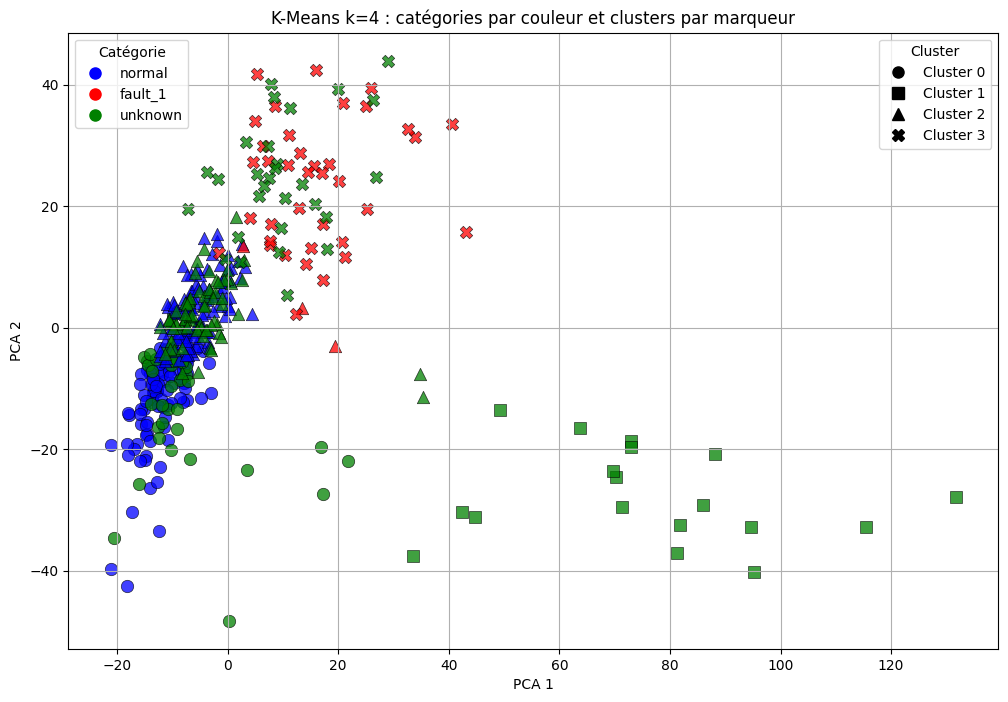

In [237]:
# ==========================================================
# PCA : couleurs = catégories, marqueurs = clusters
# ==========================================================

import matplotlib.lines as mlines

plot_df = df_all.copy()
plot_df["PCA_1"] = X_pca[:, 0]
plot_df["PCA_2"] = X_pca[:, 1]

colors = {
    "normal": "blue",
    "fault_1": "red",
    "unknown": "green"
}

markers = {
    0: "o",
    1: "s",
    2: "^",
    3: "X"
}

plt.figure(figsize=(12, 8))
ax = plt.gca()

for cluster_id in sorted(plot_df["cluster"].unique()):
    for type_name in plot_df["type"].unique():
        subset = plot_df[
            (plot_df["cluster"] == cluster_id) &
            (plot_df["type"] == type_name)
        ]

        if len(subset) > 0:
            ax.scatter(
                subset["PCA_1"],
                subset["PCA_2"],
                color=colors.get(type_name, "gray"),
                marker=markers.get(cluster_id, "o"),
                s=80,
                alpha=0.75,
                edgecolors="black",
                linewidths=0.5
            )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means k=4 : catégories par couleur et clusters par marqueur")
plt.grid(True)

# Légende couleurs
color_legend = [
    mlines.Line2D(
        [],
        [],
        color=color,
        marker="o",
        linestyle="None",
        markersize=8,
        label=label
    )
    for label, color in colors.items()
]

# Légende marqueurs
marker_legend = [
    mlines.Line2D(
        [],
        [],
        color="black",
        marker=marker,
        linestyle="None",
        markersize=8,
        label=f"Cluster {cluster_id}"
    )
    for cluster_id, marker in markers.items()
]

legend1 = ax.legend(
    handles=color_legend,
    title="Catégorie",
    loc="upper left"
)

ax.add_artist(legend1)

ax.legend(
    handles=marker_legend,
    title="Cluster",
    loc="upper right"
)

plt.show()